# EDA

### Load Packages and Data

In [43]:
# Core packages
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit prettier
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# === Load data ===
# Assumes: your notebook (.ipynb) and CSV are in the same folder
csv_path = "aeco.csv"   # change name if needed

df = pd.read_csv(csv_path)

# If you have timestamp columns, parse and sort them now
time_col = "datetime_beginning_utc"  # adjust if your main time col is different

if time_col in df.columns:
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col).reset_index(drop=True)

# Quick peek
print(df.shape)
display(df.head())


(68471, 24)


,datetime_beginning_utc,datetime_beginning_ept,nerc_region,mkt_region,zone,load_area,mw,is_verified,temp,hour,dayofweek,month,is_weekend,is_holiday,is_thanksgiving,is_thanksgiving_eve,is_black_friday,HDD,CDD,temp_rolling_24,temp_lag_24,temp_lag_168,mw_lag_24,mw_lag_168
0,2018-01-08 05:00:00,1/8/2018 12:00:00 AM,RFC,MIDATL,AE,AECO,1195.658,True,-11.7,5,0,1,0,False,False,False,False,29.7,0.0,-12.000000,-13.9,-13.9,1294.774,1261.317
1,2018-01-08 06:00:00,1/8/2018 1:00:00 AM,RFC,MIDATL,AE,AECO,1164.306,True,-8.9,6,0,1,0,False,False,False,False,26.9,0.0,-11.770833,-14.4,-12.2,1267.891,1221.330
2,2018-01-08 07:00:00,1/8/2018 2:00:00 AM,RFC,MIDATL,AE,AECO,1147.428,True,-8.9,7,0,1,0,False,False,False,False,26.9,0.0,-11.541667,-14.4,-12.8,1248.141,1190.517
3,2018-01-08 08:00:00,1/8/2018 3:00:00 AM,RFC,MIDATL,AE,AECO,1144.120,True,-8.3,8,0,1,0,False,False,False,False,26.3,0.0,-11.287500,-14.4,-13.3,1240.049,1174.050
4,2018-01-08 09:00:00,1/8/2018 4:00:00 AM,RFC,MIDATL,AE,AECO,1155.561,True,-7.2,9,0,1,0,False,False,False,False,25.2,0.0,-10.937500,-15.6,-13.3,1244.389,1168.370


Line plot for hourly load over time for the dataset

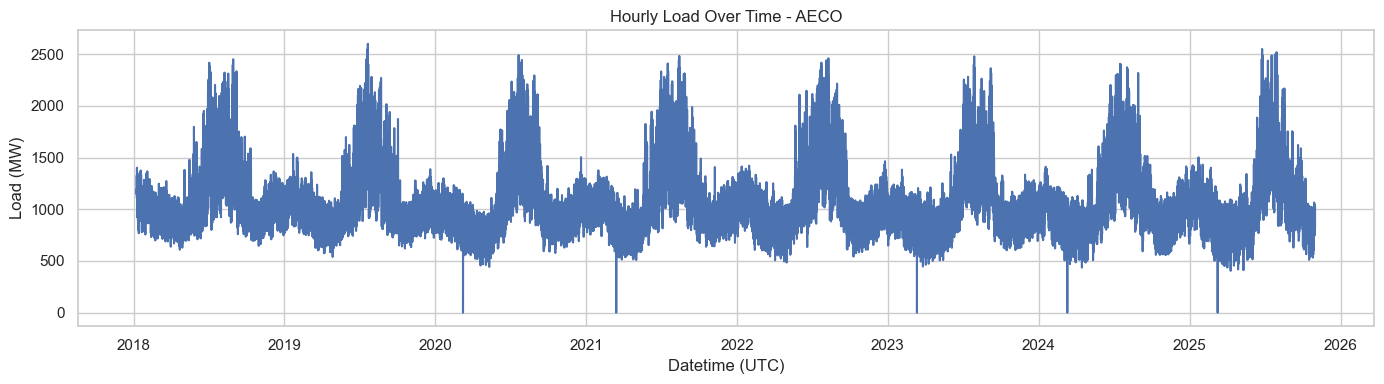

In [50]:
load_area = "AECO"  # change to a valid value from your data
df_zone = df[df["load_area"] == load_area].copy()

plt.figure(figsize=(14, 4))
plt.plot(df_zone["datetime_beginning_utc"], df_zone["mw"])
plt.xlabel("Datetime (UTC)")
plt.ylabel("Load (MW)")
plt.title(f"Hourly Load Over Time - {load_area}")
plt.tight_layout()
plt.show()

Line plot for hourly load over time for a particular month and year

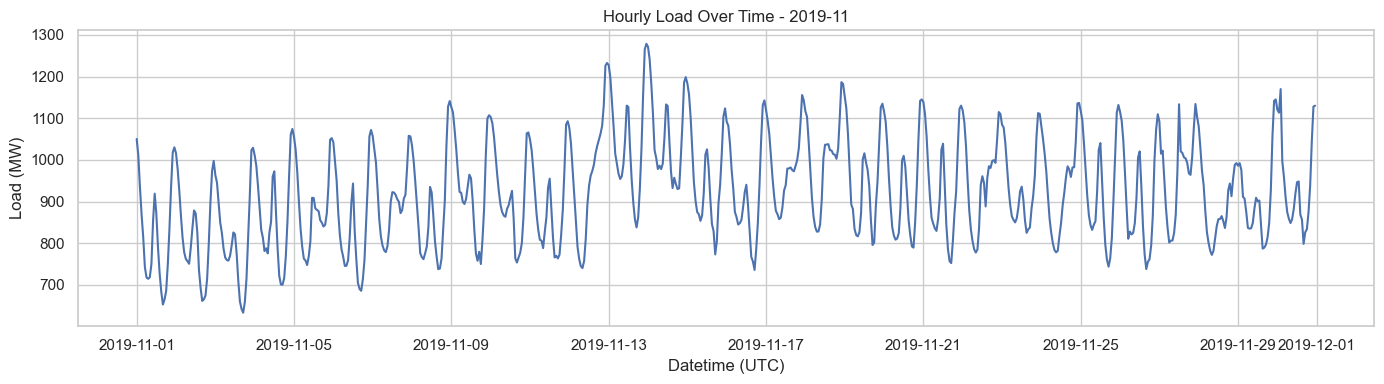

In [51]:
year = 2019
month = 11  # January

mask = (
    (df["datetime_beginning_utc"].dt.year == year) &
    (df["datetime_beginning_utc"].dt.month == month)
)

df_month = df[mask]

plt.figure(figsize=(14, 4))
plt.plot(df_month["datetime_beginning_utc"], df_month["mw"])
plt.xlabel("Datetime (UTC)")
plt.ylabel("Load (MW)")
plt.title(f"Hourly Load Over Time - {year}-{month:02d}")
plt.tight_layout()
plt.show()

How much data is missing? Counting gaps in hours and making a table.

In [52]:
df["diff"] = df["datetime_beginning_utc"].diff()
df["diff_hours"] = df["diff"].dt.total_seconds() / 3600
print(df["diff_hours"].value_counts().head(10))

diff_hours
1.0    68470
Name: count, dtype: int64


Add some columns to specify hour, date, month and season.

In [53]:
df["hour"] = df["datetime_beginning_utc"].dt.hour
df["dayofweek"] = df["datetime_beginning_utc"].dt.dayofweek  # Monday=0, Sunday=6
df["month"] = df["datetime_beginning_utc"].dt.month
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
}
df["season"] = df["month"].map(season_map)

Plot for average hourly loads across a day.

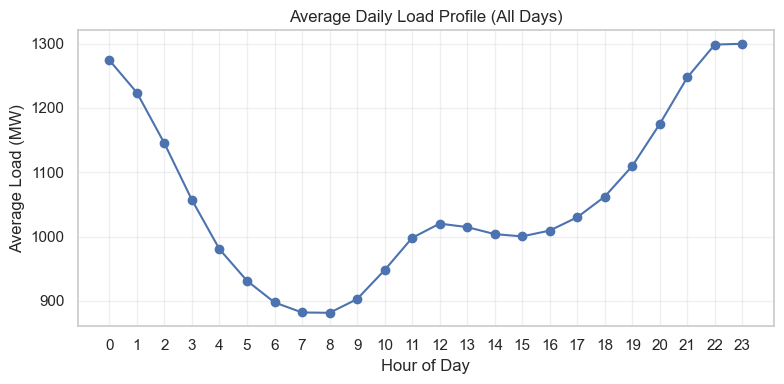

In [54]:
avg_by_hour = df.groupby("hour")["mw"].mean()

plt.figure(figsize=(8,4))
plt.plot(avg_by_hour.index, avg_by_hour.values, marker="o")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.title("Average Daily Load Profile (All Days)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot for average hourly loads across a day for weekdays and weekends.

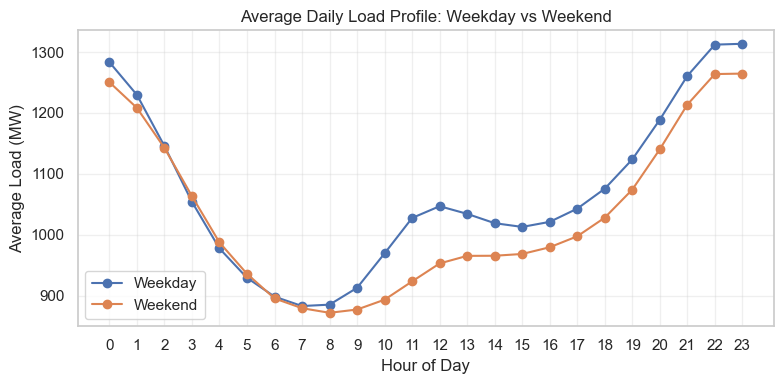

In [55]:
avg_weekday = df[df["is_weekend"] == 0].groupby("hour")["mw"].mean()
avg_weekend = df[df["is_weekend"] == 1].groupby("hour")["mw"].mean()

plt.figure(figsize=(8,4))
plt.plot(avg_weekday.index, avg_weekday.values, marker="o", label="Weekday")
plt.plot(avg_weekend.index, avg_weekend.values, marker="o", label="Weekend")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.title("Average Daily Load Profile: Weekday vs Weekend")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot for average hourly loads across a day for different seasons.

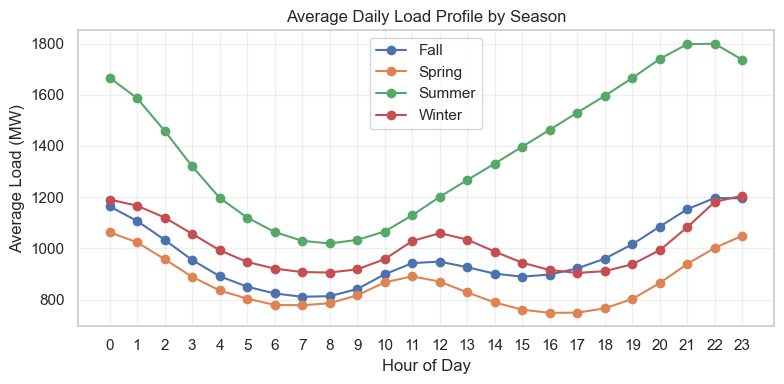

In [56]:
plt.figure(figsize=(8,4))
for season, sub in df.groupby("season"):
    sub.groupby("hour")["mw"].mean().plot(marker="o", label=season)

plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.title("Average Daily Load Profile by Season")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot for average daily load for the month of November.

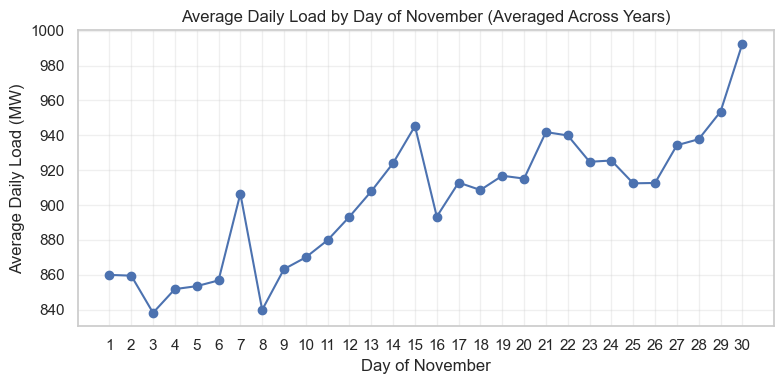

day
1     859.945601
2     859.513857
3     838.207446
4     851.797179
5     853.492185
6     856.781923
7     906.521887
8     839.902119
9     863.254714
10    870.029560
11    879.897899
12    893.354798
13    907.910982
14    924.085161
15    945.305589
16    893.385970
17    912.900833
18    908.639274
19    916.822923
20    915.190845
21    941.865173
22    939.934446
23    924.835226
24    925.559548
25    912.471655
26    912.679488
27    934.316917
28    937.779929
29    953.584077
30    992.513780
Name: daily_mean, dtype: float64


In [57]:
df_nov = df[df["datetime_beginning_utc"].dt.month == 11].copy()

# 2. Compute the mean load for each *calendar date* (year-month-day)
df_nov["date"] = df_nov["datetime_beginning_utc"].dt.date
daily_mean = df_nov.groupby("date")["mw"].mean()  # one value per actual date

# 3. Map each date to its day-of-month (1..30)
daily_mean = daily_mean.to_frame(name="daily_mean")
daily_mean["day"] = pd.to_datetime(daily_mean.index).day

# 4. For each day-of-month, average over all years
avg_by_daynum = daily_mean.groupby("day")["daily_mean"].mean()

# 5. Plot
plt.figure(figsize=(8, 4))
plt.plot(avg_by_daynum.index, avg_by_daynum.values, marker="o")
plt.xticks(range(1, avg_by_daynum.index.max() + 1))
plt.xlabel("Day of November")
plt.ylabel("Average Daily Load (MW)")
plt.title("Average Daily Load by Day of November (Averaged Across Years)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(avg_by_daynum)

Load versus Temperature. Notice the U-shape!

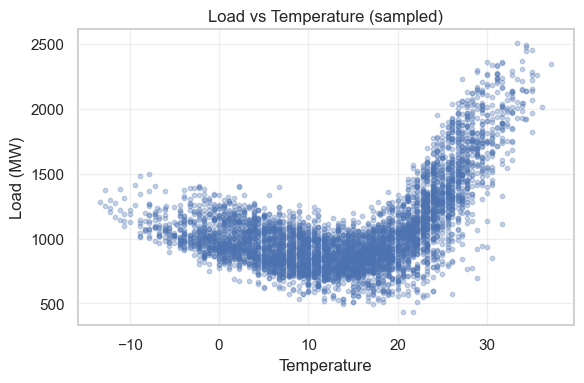

In [58]:
plot_sample = df.sample(n=min(5000, len(df)), random_state=0)

plt.figure(figsize=(6, 4))
plt.scatter(plot_sample["temp"], plot_sample["mw"], alpha=0.3, s=10)
plt.xlabel("Temperature")
plt.ylabel("Load (MW)")
plt.title("Load vs Temperature (sampled)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Load versus Temperature for different seasons.

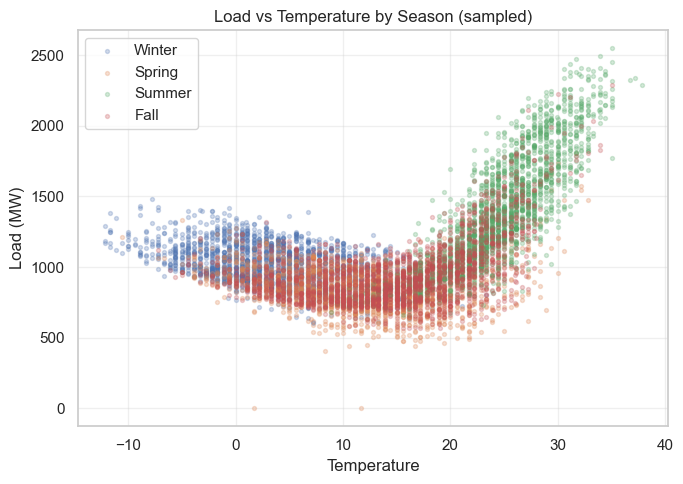

In [59]:
# Sample for plotting
plot_sample = df.sample(n=min(8000, len(df)), random_state=1)

plt.figure(figsize=(7, 5))
for season in ["Winter", "Spring", "Summer", "Fall"]:
    sub = plot_sample[plot_sample["season"] == season]
    if len(sub) == 0:
        continue
    plt.scatter(sub["temp"], sub["mw"], alpha=0.25, s=8, label=season)

plt.xlabel("Temperature")
plt.ylabel("Load (MW)")
plt.title("Load vs Temperature by Season (sampled)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Load versus Temperature for Day and Night.

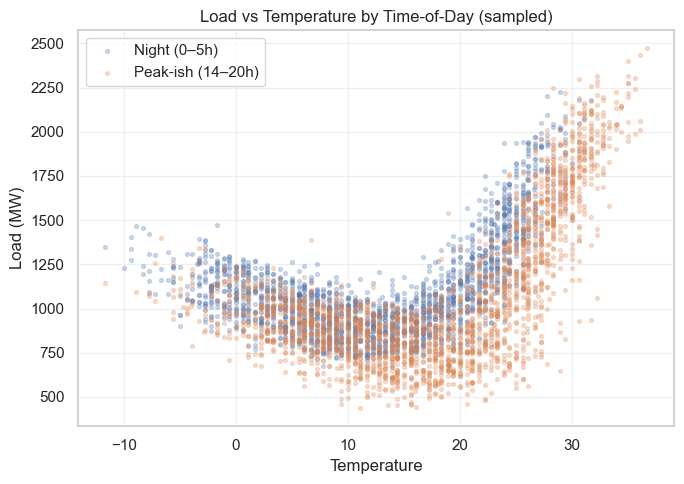

In [60]:
plot_sample = df.sample(n=min(8000, len(df)), random_state=2)

# Define two hour bands
peak_mask = plot_sample["hour"].between(14, 20)   # 2pm–8pm (adjust if you like)
night_mask = plot_sample["hour"].between(0, 5)    # midnight–5am

plt.figure(figsize=(7, 5))

plt.scatter(plot_sample[night_mask]["temp"],
            plot_sample[night_mask]["mw"],
            alpha=0.25, s=8, label="Night (0–5h)")

plt.scatter(plot_sample[peak_mask]["temp"],
            plot_sample[peak_mask]["mw"],
            alpha=0.25, s=8, label="Peak-ish (14–20h)")

plt.xlabel("Temperature")
plt.ylabel("Load (MW)")
plt.title("Load vs Temperature by Time-of-Day (sampled)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Scatterplot for Load 24 hours ago and Load now.

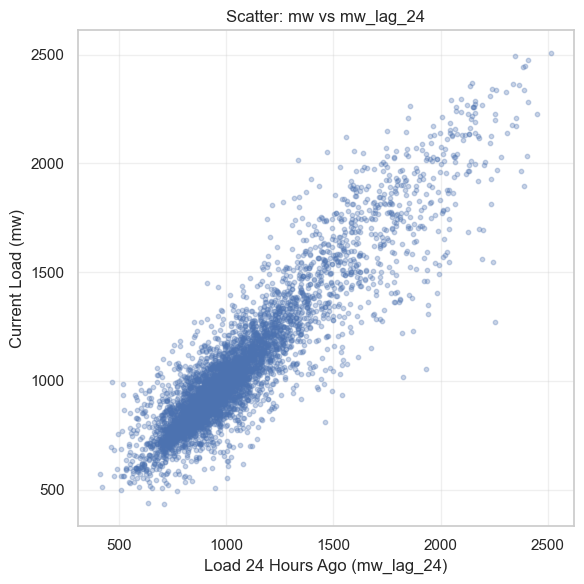

In [61]:
lag_df = df[["mw", "mw_lag_24"]].dropna()

# Optional: sample to avoid overplotting
sample_size = min(5000, len(lag_df))
plot_sample = lag_df.sample(n=sample_size, random_state=0)

plt.figure(figsize=(6, 6))
plt.scatter(plot_sample["mw_lag_24"], plot_sample["mw"], alpha=0.3, s=10)
plt.xlabel("Load 24 Hours Ago (mw_lag_24)")
plt.ylabel("Current Load (mw)")
plt.title("Scatter: mw vs mw_lag_24")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Scatterplot for Load one week ago and Load now.

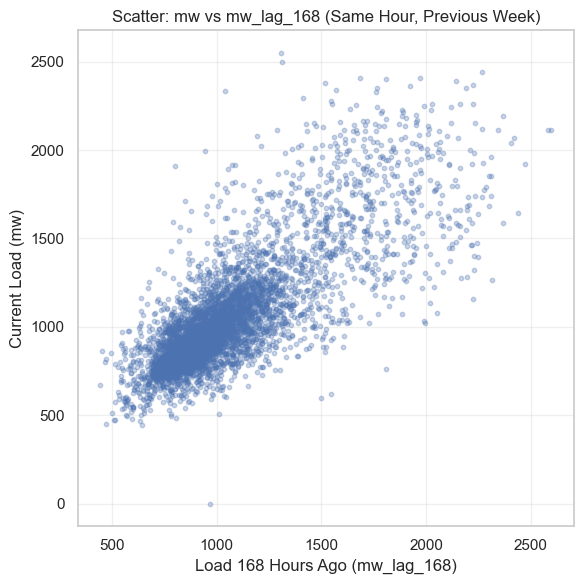

In [62]:
# Keep only rows where both mw and mw_lag_168 are present
lag168_df = df[["mw", "mw_lag_168"]].dropna()

# Optional: sample to avoid overplotting
sample_size = min(5000, len(lag168_df))
plot_sample_168 = lag168_df.sample(n=sample_size, random_state=1)

plt.figure(figsize=(6, 6))
plt.scatter(plot_sample_168["mw_lag_168"], plot_sample_168["mw"], alpha=0.3, s=10)
plt.xlabel("Load 168 Hours Ago (mw_lag_168)")
plt.ylabel("Current Load (mw)")
plt.title("Scatter: mw vs mw_lag_168 (Same Hour, Previous Week)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

What if we predicted the hourly load only using the true hourly load from 24 hours ago? Histogram of errors and forecast error over time.

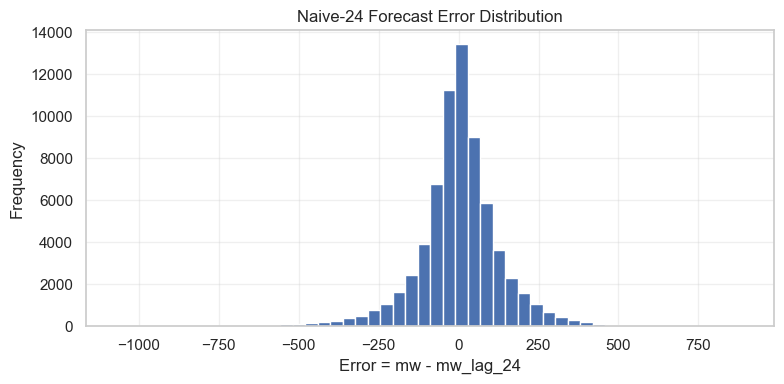

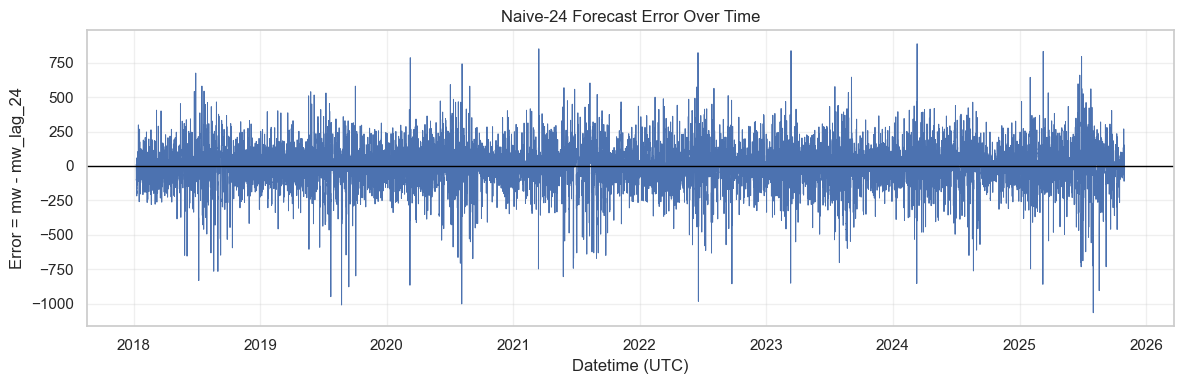

Mean error: -0.14342685224401577
Std dev error: 133.54018540588783


In [63]:
df["err_24"] = df["mw"] - df["mw_lag_24"]

# Drop rows where lag is missing (e.g. first 24 hours)
err_df = df.dropna(subset=["err_24", "mw_lag_24", "datetime_beginning_utc"]).copy()

# 3. Histogram of errors
plt.figure(figsize=(8, 4))
plt.hist(err_df["err_24"], bins=50)
plt.xlabel("Error = mw - mw_lag_24")
plt.ylabel("Frequency")
plt.title("Naive-24 Forecast Error Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Error over time
plt.figure(figsize=(12, 4))
plt.plot(err_df["datetime_beginning_utc"], err_df["err_24"], linewidth=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Datetime (UTC)")
plt.ylabel("Error = mw - mw_lag_24")
plt.title("Naive-24 Forecast Error Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (Optional) quick sanity print
print("Mean error:", err_df["err_24"].mean())
print("Std dev error:", err_df["err_24"].std())

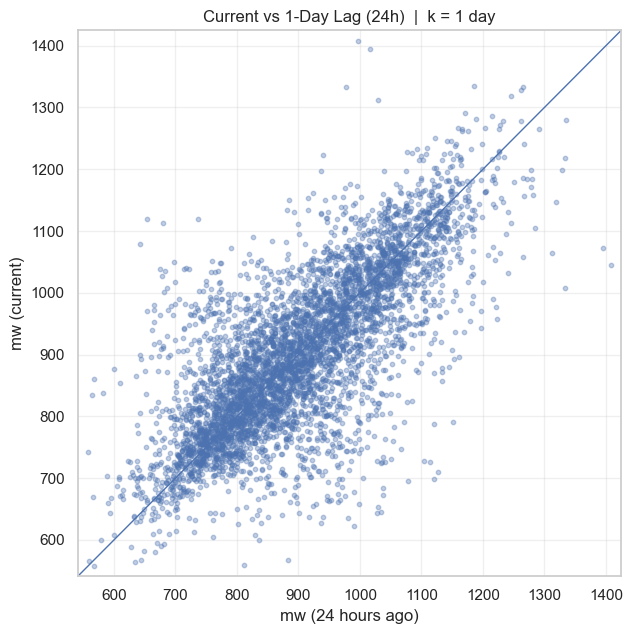

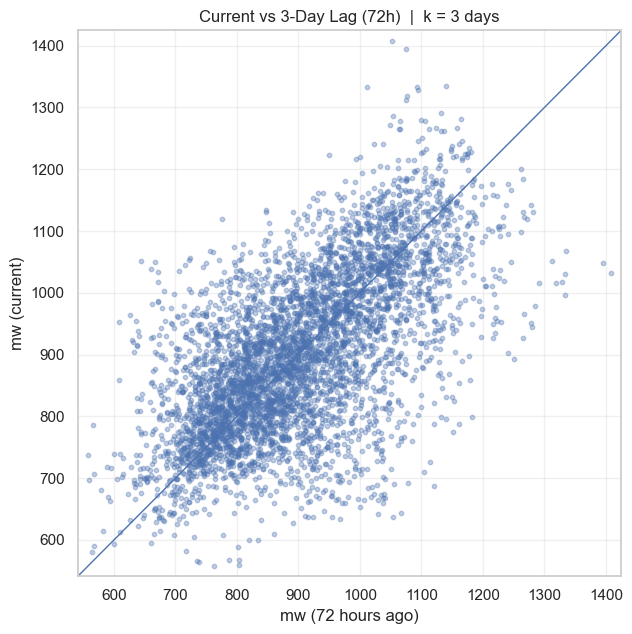

In [48]:
def plot_load_vs_kday_lag(
    df,
    k_days,
    year=None,
    month=None,
    day=None,
    time_col="datetime_beginning_utc",
    load_col="mw",
    max_points_scatter=20000,   # above this, switch to hexbin
    sample_points=5000,         # downsample for scatter if very large
):
    """
    Scatter (or hexbin) of current hourly load vs load k-days ago (k*24 hours).
    Optional filters for year / month / day on the *current* timestamp.

    Parameters
    ----------
    df : DataFrame with datetime + load columns
    k_days : int, number of days for the lag (k*24 hours)
    year, month, day : optional ints to filter (e.g., year=2019, month=11, day=26)
    time_col : name of datetime column
    load_col : name of load column
    max_points_scatter : threshold above which we use hexbin for speed/clarity
    sample_points : if using scatter and points > sample_points, random sample
    """

    # 1) Ensure datetime and sorted
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df = df.copy()
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values(time_col)

    # 2) Optional filter by year/month/day on the CURRENT hour
    mask = pd.Series(True, index=df.index)
    if year is not None:
        mask &= df[time_col].dt.year.eq(year)
    if month is not None:
        mask &= df[time_col].dt.month.eq(month)
    if day is not None:
        mask &= df[time_col].dt.day.eq(day)

    dff = df.loc[mask].copy()

    # 3) Build lag (k * 24 hours)
    lag_hours = int(k_days) * 24
    lag_col = f"{load_col}_lag_{lag_hours}h"
    dff[lag_col] = dff[load_col].shift(lag_hours)

    # 4) Drop rows without valid lag
    plot_df = dff[[time_col, load_col, lag_col]].dropna().copy()
    if plot_df.empty:
        print("No data to plot after applying lag and filters. "
              "Check that your date filter overlaps with available history.")
        return

    # 5) Decide plot type (scatter vs hexbin)
    n = len(plot_df)
    x = plot_df[lag_col].to_numpy()
    y = plot_df[load_col].to_numpy()

    # Axis limits + y=x reference
    xy_min = np.nanmin([x.min(), y.min()])
    xy_max = np.nanmax([x.max(), y.max()])
    pad = 0.02 * (xy_max - xy_min if xy_max > xy_min else 1.0)
    xlim = (xy_min - pad, xy_max + pad)
    ylim = (xy_min - pad, xy_max + pad)

    # 6) Plot
    plt.figure(figsize=(6.5, 6.5))

    title_bits = [f"k = {k_days} day{'s' if k_days != 1 else ''}"]
    if year is not None:  title_bits.append(f"year={year}")
    if month is not None: title_bits.append(f"month={month}")
    if day is not None:   title_bits.append(f"day={day}")
    title = " | ".join(title_bits)

    if n > max_points_scatter:
        # Hexbin for dense plots
        hb = plt.hexbin(x, y, gridsize=50, bins='log')
        plt.colorbar(hb, label="log10(count)")
    else:
        # Scatter (optionally downsample for speed)
        if n > sample_points:
            idx = np.random.RandomState(0).choice(n, size=sample_points, replace=False)
            xs, ys = x[idx], y[idx]
        else:
            xs, ys = x, y
        plt.scatter(xs, ys, alpha=0.35, s=10)

    # y = x reference line
    diag = np.linspace(*xlim, 200)
    plt.plot(diag, diag, linewidth=1)

    plt.xlabel(f"{load_col} ({lag_hours} hours ago)")
    plt.ylabel(f"{load_col} (current)")
    plt.title(f"Current vs {k_days}-Day Lag ({lag_hours}h)  |  {title}")
    plt.xlim(xlim); plt.ylim(ylim)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# -------------------------
# Example usages:
# -------------------------

# 1) Compare to 1-day lag for all data
# plot_load_vs_kday_lag(df, k_days=3)

# 2) Compare to 7-day lag for all data
# plot_load_vs_kday_lag(df, k_days=7)

# 3) Focus on November across all years, 1-day lag
plot_load_vs_kday_lag(df[df["datetime_beginning_utc"].dt.month == 11], k_days=1)
plot_load_vs_kday_lag(df[df["datetime_beginning_utc"].dt.month == 11], k_days=3)


# 4) Focus on a specific month & year (e.g., Nov 2016), 7-day lag
# plot_load_vs_kday_lag(df, k_days=7, year=2016, month=11)

# 5) Focus on a specific single day (e.g., 2016-11-15), 1-day lag
# plot_load_vs_kday_lag(df, k_days=1, year=2016, month=11, day=15)


In [70]:
def add_missing_24h_spaced_lags(
    df,
    time_col="datetime_beginning_utc",
    y_col="mw",
    w_col="temp",
    ks=(3,4,5,6,7),          # -> hours = 24*k
    group_cols=None          # auto-detects ['load_area'] if not provided and present
):
    """
    Create only the missing 24h-spaced lag columns for y_col and w_col:
      {y_col}_lag_{24k}, {w_col}_lag_{24k} for k in ks (default 72..168).
    Existing columns are left as-is.

    Sorting is done by time within groups to ensure correct alignment.
    Returns: (df, created_cols)  -- df is modified in place and also returned.
    """
    d = df  # modify in place on purpose

    # Ensure datetime dtype (don’t force any timezone changes)
    if not pd.api.types.is_datetime64_any_dtype(d[time_col]):
        d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    # Auto group detection
    if group_cols is None:
        if "load_area" in d.columns and d["load_area"].nunique() > 1:
            group_cols = ["load_area"]
        else:
            group_cols = []

    # Sort by time within groups
    if group_cols:
        d.sort_values(group_cols + [time_col], inplace=True)
    else:
        d.sort_values(time_col, inplace=True)

    created = []

    # Helper to shift within groups or globally
    def _shift_series(colname, hours):
        if colname not in d.columns:
            # If the source column doesn't exist, skip silently
            return None
        out_name = f"{colname}_lag_{hours}"
        if out_name in d.columns:
            return None  # already present
        if group_cols:
            d[out_name] = d.groupby(group_cols)[colname].shift(hours)
        else:
            d[out_name] = d[colname].shift(hours)
        return out_name

    for k in ks:
        h = 24 * k
        # create y lags if missing
        y_created = _shift_series(y_col, h)
        if y_created: created.append(y_created)
        # create weather lags if missing
        w_created = _shift_series(w_col, h)
        if w_created: created.append(w_created)

    # Quick summary
    if created:
        print("Created lag columns:")
        for c in created:
            n_na = d[c].isna().sum()
            print(f"  • {c}  (NaNs introduced: {n_na})")
    else:
        print("No new lag columns were needed; all requested 24h-spaced lags already exist.")

    return d, created

# -----------------------------
# Example usage on your df:
# -----------------------------
df, created_cols = add_missing_24h_spaced_lags(
     df,
     time_col="datetime_beginning_utc",
     y_col="mw",
     w_col="temp",
     ks=(3,4,5,6,7)  # -> 72,96,120,144,168
 )


Created lag columns:
  • mw_lag_72  (NaNs introduced: 72)
  • temp_lag_72  (NaNs introduced: 72)
  • mw_lag_96  (NaNs introduced: 96)
  • temp_lag_96  (NaNs introduced: 96)
  • mw_lag_120  (NaNs introduced: 120)
  • temp_lag_120  (NaNs introduced: 120)
  • mw_lag_144  (NaNs introduced: 144)
  • temp_lag_144  (NaNs introduced: 144)


In [71]:
def split_time_series_with_gaps_df(
    df,
    time_col="datetime_beginning_utc",
    covid_exclude=("2020-03-15 00:00:00", "2020-06-30 23:59:59"),  # set to None to keep all rows
    train_frac=0.70,
    val_frac=0.15,
    gap_hours=168,
):
    """
    Train | gap | Val | gap | Test split that AUTO-matches your time format.

    - If your column is tz-naive (dtype datetime64[ns]), we keep everything naive
      and create naive cutoff timestamps.
    - If your column is tz-aware, we convert to UTC and use UTC-aware cutoffs.

    Returns: train_df, val_df, test_df, summary_dict
    """

    d = df.copy()

    # --- Ensure datetime type; do not force timezone yet ---
    if not pd.api.types.is_datetime64_any_dtype(d[time_col]):
        d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    # Detect tz awareness
    is_tz_aware = pd.api.types.is_datetime64tz_dtype(d[time_col])

    # Normalize to one consistent timeline
    if is_tz_aware:
        # Keep tz-aware; convert everything to UTC for clean math
        d[time_col] = d[time_col].dt.tz_convert("UTC")
        # Helper to build UTC-aware cutoffs
        def _ts(s): return pd.Timestamp(s, tz="UTC")
    else:
        # Keep naive timeline (no tz)
        d[time_col] = d[time_col].dt.tz_localize(None)
        # Helper to build naive cutoffs
        def _ts(s): return pd.Timestamp(s)

    d = d.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    # --- Exclude peak-COVID (optional) ---
    if covid_exclude is not None:
        covid_start = _ts(covid_exclude[0])
        covid_end   = _ts(covid_exclude[1])
        mask_covid = (d[time_col] >= covid_start) & (d[time_col] <= covid_end)
        d = d.loc[~mask_covid].copy()

    # --- Compute boundaries with gaps ---
    gap = pd.Timedelta(hours=gap_hours)
    tmin, tmax = d[time_col].min(), d[time_col].max()
    total_span = tmax - tmin
    eff_span = total_span - 2 * gap
    if eff_span <= pd.Timedelta(0):
        raise ValueError("Time span too short for the requested gaps. Increase range or reduce gap_hours.")

    train_end = tmin + eff_span * train_frac
    val_end   = train_end + gap + eff_span * val_frac

    mask_train = d[time_col] <= train_end
    mask_val   = (d[time_col] > train_end + gap) & (d[time_col] <= val_end)
    mask_test  = d[time_col] > val_end + gap

    train_df = d.loc[mask_train].copy()
    val_df   = d.loc[mask_val].copy()
    test_df  = d.loc[mask_test].copy()

    summary = {
        "time_col": time_col,
        "dtype": str(d[time_col].dtype),
        "time_min": tmin.isoformat(),
        "train_last": train_end.isoformat(),
        "val_last": val_end.isoformat(),
        "time_max": tmax.isoformat(),
        "gap_hours": gap_hours,
        "rows_train": len(train_df),
        "rows_val": len(val_df),
        "rows_test": len(test_df),
        "covid_excluded": covid_exclude is not None,
        "covid_window": None if covid_exclude is None else (str(covid_start), str(covid_end)),
    }
    return train_df, val_df, test_df, summary

# ----------------------------
# Example usage on your df
# ----------------------------
train_df, val_df, test_df, info = split_time_series_with_gaps_df(
     df,
     time_col="datetime_beginning_utc",
     covid_exclude=("2020-03-15 00:00:00", "2020-06-30 23:59:59"),  # or None
     train_frac=0.70,
     val_frac=0.15,
     gap_hours=168
 )
print(info)


{'time_col': 'datetime_beginning_utc', 'dtype': 'datetime64[ns]', 'time_min': '2018-01-08T05:00:00', 'train_last': '2023-06-18T10:48:00', 'val_last': '2024-08-24T06:54:00', 'time_max': '2025-10-31T03:00:00', 'gap_hours': 168, 'rows_train': 45102, 'rows_val': 10220, 'rows_test': 10221, 'covid_excluded': True, 'covid_window': ('2020-03-15 00:00:00', '2020-06-30 23:59:59')}


/var/folders/3f/lwct3zl95g5b4n70t0rh3h_m0000gr/T/ipykernel_66152/2189043774.py:26: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  is_tz_aware = pd.api.types.is_datetime64tz_dtype(d[time_col])


In [69]:
print(train_df.head)

<bound method NDFrame.head of       datetime_beginning_utc datetime_beginning_ept nerc_region mkt_region zone load_area        mw  is_verified  \
0        2018-01-08 05:00:00   1/8/2018 12:00:00 AM         RFC     MIDATL   AE      AECO  1195.658         True   
1        2018-01-08 06:00:00    1/8/2018 1:00:00 AM         RFC     MIDATL   AE      AECO  1164.306         True   
2        2018-01-08 07:00:00    1/8/2018 2:00:00 AM         RFC     MIDATL   AE      AECO  1147.428         True   
3        2018-01-08 08:00:00    1/8/2018 3:00:00 AM         RFC     MIDATL   AE      AECO  1144.120         True   
4        2018-01-08 09:00:00    1/8/2018 4:00:00 AM         RFC     MIDATL   AE      AECO  1155.561         True   
...                      ...                    ...         ...        ...  ...       ...       ...          ...   
47689    2023-06-18 06:00:00   6/18/2023 2:00:00 AM         RFC     MIDATL   AE      AECO   830.868         True   
47690    2023-06-18 07:00:00   6/18/2023 3

In [77]:
# ==== Part 2: ENet lag selection -> Post-Lasso Ridge (tailored to your CSV columns) ====

import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, Ridge
from sklearn.metrics import mean_squared_error

# ---- Config (match your CSV) ----
TIME_COL = "datetime_beginning_utc"
Y_COL    = "mw"
TEMP_COL = "temp"

# Optional extras the CSV already had (only used if present)
OPTIONAL_NUMERIC = ["CDD", "HDD", "temp_rolling_24"]  # add more if you want
OPTIONAL_CATS    = [
    "is_holiday", "is_weekend",
    "blackFriday", "thanksgiving", "thanksgiving_eve",
    "is_black_friday", "is_thanksgiving", "is_thanksgiving_eve"
]

# ---- Helper: ensure calendar cols exist without overwriting yours ----
def ensure_calendar(d):
    d = d.copy()
    if "hour" not in d.columns:
        d["hour"] = pd.to_datetime(d[TIME_COL]).dt.hour
    # prefer existing 'dayofweek' if present
    if "dow" not in d.columns:
        if "dayofweek" in d.columns:
            d["dow"] = d["dayofweek"].astype(int)
        else:
            d["dow"] = pd.to_datetime(d[TIME_COL]).dt.dayofweek
    if "month" not in d.columns:
        d["month"] = pd.to_datetime(d[TIME_COL]).dt.month
    # cast known boolean-ish flags to bool if present
    for c in OPTIONAL_CATS:
        if c in d.columns:
            d[c] = d[c].astype(bool)
    return d

train_df = ensure_calendar(train_df)
val_df   = ensure_calendar(val_df)
test_df  = ensure_calendar(test_df)

# ---- Detect 24h-spaced lag columns (>=72h only) ----
def detect_lags(frame, base_name, allowed_hours=(72,96,120,144,168)):
    pat = re.compile(rf"^{re.escape(base_name)}_lag_(\d+)$")
    cols = []
    for c in frame.columns:
        m = pat.match(c)
        if m:
            h = int(m.group(1))
            if h in allowed_hours:
                cols.append((h, c))
    return [c for _, c in sorted(cols)]

mw_lags   = detect_lags(train_df, Y_COL)
temp_lags = detect_lags(train_df, TEMP_COL)
lag_block_cols = mw_lags + temp_lags

if not lag_block_cols:
    raise ValueError("No 24h-spaced lag columns (72..168) found. "
                     "Expected names like mw_lag_72, temp_lag_96, etc.")

# ---- HARD DROP: remove any rows with NaNs in lag columns + core vars ----
drop_cols = lag_block_cols + [Y_COL, TEMP_COL]

train_df = train_df.dropna(subset=drop_cols).copy()
val_df   = val_df.dropna(subset=drop_cols).copy()
test_df  = test_df.dropna(subset=drop_cols).copy()

print("\nAfter dropping NaNs from lags + core variables:")
print(f"  TRAIN rows: {train_df.shape[0]}")
print(f"  VAL rows:   {val_df.shape[0]}")
print(f"  TEST rows:  {test_df.shape[0]}")

# ---- Stage A: Elastic Net selection on lag blocks (TRAIN only) ----
sel_scaler = StandardScaler()
Xtrain_lags = sel_scaler.fit_transform(train_df[lag_block_cols].values)
ytrain      = train_df[Y_COL].values

enet = ElasticNetCV(
    l1_ratio=[0.2, 0.4, 0.6],   # small, stable grid
    alphas=None,                # search full path
    cv=3,
    max_iter=5000,
    random_state=0
).fit(Xtrain_lags, ytrain)

coef = enet.coef_
selected_idx = np.where(coef != 0)[0]
selected_lag_cols = [lag_block_cols[i] for i in selected_idx]

# Fallback if ENet is very ridge-y and selects nothing
if len(selected_lag_cols) == 0:
    corr = train_df[lag_block_cols].corrwith(train_df[Y_COL]).abs().sort_values(ascending=False)
    selected_lag_cols = list(corr.head(2).index)

print("Selected lag features:")
for c in selected_lag_cols:
    print("  •", c)

# ---- Stage B: Post-Lasso Ridge with calendar + target-hour weather + selected lags ----
# Categorical set (only those that are actually present)
base_cat = ["hour", "dow", "month"]
present_flags = [c for c in OPTIONAL_CATS if c in train_df.columns]
cat_cols = base_cat + present_flags

# Numeric set = target-hour weather + optional numeric extras (if present) + selected lags
num_base = [col for col in [TEMP_COL] + OPTIONAL_NUMERIC if col in train_df.columns]
num_cols = num_base + selected_lag_cols

# In case any optional numeric columns have NaNs, clean again on the exact feature set
needed_cols = cat_cols + num_cols + [Y_COL]
train_df_B = train_df.dropna(subset=needed_cols).copy()
val_df_B   = val_df.dropna(subset=needed_cols).copy()
test_df_B  = test_df.dropna(subset=needed_cols).copy()

print("\nAfter final NaN drop on all used features:")
print(f"  TRAIN (B) rows: {train_df_B.shape[0]}")
print(f"  VAL   (B) rows: {val_df_B.shape[0]}")
print(f"  TEST  (B) rows: {test_df_B.shape[0]}")

# Build transformer & model
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

model = Pipeline([
    ("prep", pre),
    ("ridge", Ridge(alpha=10.0))
])

# ---- Fit on TRAIN, evaluate on VAL ----
Xtr = train_df_B[cat_cols + num_cols]
ytr = train_df_B[Y_COL].values
Xva = val_df_B[cat_cols + num_cols]
yva = val_df_B[Y_COL].values

model.fit(Xtr, ytr)
pred_val = model.predict(Xva)
rmse_val = np.sqrt(mean_squared_error(yva, pred_val))
print(f"\n[VAL] RMSE (post-Lasso Ridge): {rmse_val:0.3f}")

# Baselines (only if the cols exist, and drop NaNs rowwise)
def baseline_rmse(df_part, hours):
    col = f"{Y_COL}_lag_{hours}"
    if col in df_part.columns:
        tmp = df_part[[Y_COL, col]].dropna()
        if tmp.empty:
            return None
        return np.sqrt(mean_squared_error(tmp[Y_COL], tmp[col]))
    return None

for h in (72, 168):
    r = baseline_rmse(val_df_B, h)
    if r is not None:
        print(f"[VAL] Naive-{h} RMSE: {r:0.3f}")

# ---- Refit on TRAIN+VAL, evaluate on TEST ----
trainval_df = pd.concat([train_df_B, val_df_B], axis=0).sort_values(TIME_COL)
Xtva = trainval_df[cat_cols + num_cols]
ytva = trainval_df[Y_COL].values
Xte  = test_df_B[cat_cols + num_cols]
yte  = test_df_B[Y_COL].values

model.fit(Xtva, ytva)
pred_test = model.predict(Xte)
rmse_test = np.sqrt(mean_squared_error(yte, pred_test))
print(f"\n[TEST] RMSE (post-Lasso Ridge): {rmse_test:0.3f}")

for h in (72, 168):
    r = baseline_rmse(test_df_B, h)
    if r is not None:
        print(f"[TEST] Naive-{h} RMSE: {r:0.3f}")

print("\nCategorical features used:", cat_cols)
print("Numeric (unpenalized + selected lags) used:", num_cols)



After dropping NaNs from lags + core variables:
  TRAIN rows: 44958
  VAL rows:   10220
  TEST rows:  10221
Selected lag features:
  • mw_lag_72
  • mw_lag_96
  • mw_lag_120
  • mw_lag_144
  • mw_lag_168
  • temp_lag_72
  • temp_lag_96
  • temp_lag_120
  • temp_lag_144
  • temp_lag_168

After final NaN drop on all used features:
  TRAIN (B) rows: 44958
  VAL   (B) rows: 10220
  TEST  (B) rows: 10221

[VAL] RMSE (post-Lasso Ridge): 109.896
[VAL] Naive-72 RMSE: 192.171
[VAL] Naive-168 RMSE: 226.307

[TEST] RMSE (post-Lasso Ridge): 115.885
[TEST] Naive-72 RMSE: 200.771
[TEST] Naive-168 RMSE: 217.989

Categorical features used: ['hour', 'dow', 'month', 'is_holiday', 'is_weekend', 'is_black_friday', 'is_thanksgiving', 'is_thanksgiving_eve']
Numeric (unpenalized + selected lags) used: ['temp', 'CDD', 'HDD', 'temp_rolling_24', 'mw_lag_72', 'mw_lag_96', 'mw_lag_120', 'mw_lag_144', 'mw_lag_168', 'temp_lag_72', 'temp_lag_96', 'temp_lag_120', 'temp_lag_144', 'temp_lag_168']


In [78]:
# ==== Inspect Ridge coefficients (after final TRAIN+VAL fit) ====

# Grab the fitted preprocessor and ridge model
prep  = model.named_steps["prep"]
ridge = model.named_steps["ridge"]

# 1) Reconstruct feature names in the same order ColumnTransformer produced them

# Numeric features: exactly num_cols, in the same order we passed into ColumnTransformer
num_feature_names = list(num_cols)

# Categorical features: OneHotEncoder expands each original column into many dummy vars
cat_encoder = prep.named_transformers_["cat"]
cat_feature_names = []

for col_name, cats in zip(cat_cols, cat_encoder.categories_):
    for cat in cats:
        cat_feature_names.append(f"{col_name}={cat}")

full_feature_names = num_feature_names + cat_feature_names

# 2) Extract coefficients from Ridge and build a dataframe

coef = ridge.coef_.ravel()  # shape (n_features,)
intercept = ridge.intercept_

coef_df = pd.DataFrame({
    "feature": full_feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\nRidge intercept (after standardization & one-hot):", intercept)

print("\nTop 20 features by |coefficient|:")
print(coef_df.head(20).to_string(index=False))

# 3) Optional: group-level importance by base feature name
# (e.g., all dummies for 'hour' grouped together, all lags by their original column name)

group_importance = (
    coef_df
    .assign(group=lambda df: df["feature"].str.replace(r"=.*", "", regex=True))
    .groupby("group")["abs_coef"]
    .sum()
    .sort_values(ascending=False)
)

print("\nGroup-wise importance (sum of |coef| within each original feature):")
print(group_importance.to_string())



Ridge intercept (after standardization & one-hot): 1038.3969207443533

Top 20 features by |coefficient|:
        feature       coef   abs_coef
            CDD 193.043341 193.043341
        hour=23 158.004703 158.004703
         hour=0 154.021286 154.021286
        hour=22 146.751865 146.751865
         hour=1 129.482010 129.482010
            HDD 111.128984 111.128984
        hour=21 103.181043 103.181043
         hour=8 -98.552758  98.552758
         hour=7 -98.280982  98.280982
        month=7  93.544838  93.544838
         hour=6 -87.649030  87.649030
         hour=9 -84.347696  84.347696
         hour=2  78.964061  78.964061
        month=8  73.521569  73.521569
        month=4 -69.345670  69.345670
temp_rolling_24  68.924187  68.924187
         hour=5 -65.351828  65.351828
        hour=16 -59.135384  59.135384
        hour=15 -55.754240  55.754240
        hour=10 -53.791866  53.791866

Group-wise importance (sum of |coef| within each original feature):
group
hour                 

In [79]:
print("\n=== Split date ranges BEFORE lag/NaN drops ===")
for name, frame in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    print(
        f"{name}: {frame[TIME_COL].min()}  ->  {frame[TIME_COL].max()}  "
        f"(n={len(frame)})"
    )


=== Split date ranges BEFORE lag/NaN drops ===
TRAIN: 2018-01-14 05:00:00  ->  2023-06-18 10:00:00  (n=44958)
VAL: 2023-06-25 11:00:00  ->  2024-08-24 06:00:00  (n=10220)
TEST: 2024-08-31 07:00:00  ->  2025-10-31 03:00:00  (n=10221)
